In [4]:
import mlflow
import mlflow.transformers
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("flickr8k-image-captioning")

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("✅ Model loaded")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ Model loaded


In [6]:
import mlflow
from mlflow import MlflowClient
import os

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("flickr8k-image-captioning")

with mlflow.start_run(run_name="week2_best_model_registration") as run:
    
    mlflow.log_param("model_name", "Salesforce/blip-image-captioning-base")
    mlflow.log_param("decoding_strategy", "greedy")
    mlflow.log_param("fine_tuned", False)
    
    save_path = "../models/blip_baseline"
    os.makedirs(save_path, exist_ok=True)
    model.save_pretrained(save_path)
    processor.save_pretrained(save_path)
    
    mlflow.log_artifacts(save_path, artifact_path="blip_model")
    
    run_id = run.info.run_id
    print(f"✅ Model saved and logged as artifact. Run ID: {run_id}")

client = MlflowClient()

try:
    client.create_registered_model("flickr8k-blip-baseline")
except Exception:
    pass  # already exists, that's fine

model_version = client.create_model_version(
    name="flickr8k-blip-baseline",
    source=f"runs:/{run_id}/blip_model",
    run_id=run_id
)

print(f"✅ Registered as version {model_version.version}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved and logged as artifact. Run ID: fcdd3c1415cc403e9caeda1e8fa81400
🏃 View run week2_best_model_registration at: http://localhost:5000/#/experiments/1/runs/fcdd3c1415cc403e9caeda1e8fa81400
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/31 08:23:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: flickr8k-blip-baseline, version 1


✅ Registered as version 1


In [7]:
from mlflow import MlflowClient

client = MlflowClient()
registered_models = client.search_registered_models()

for rm in registered_models:
    print(f"Model: {rm.name}")
    for version in client.search_model_versions(f"name='{rm.name}'"):
        print(f"  Version: {version.version}, Stage: {version.current_stage}")

Model: flickr8k-blip-baseline
  Version: 1, Stage: None


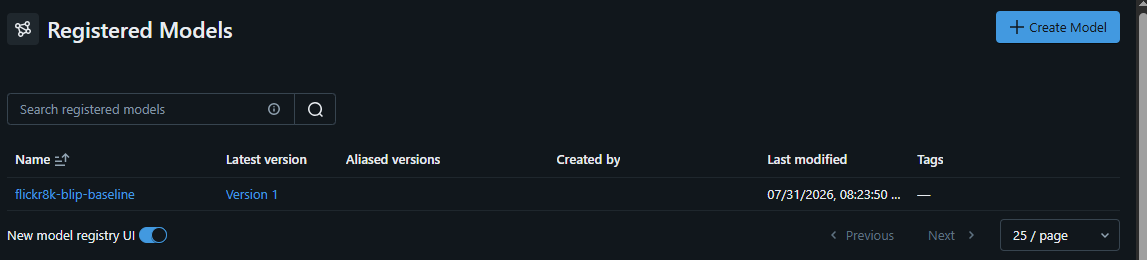